## LSTM Model - BG Forecasting

In [1]:
!pip install -r ../requirements.txt

## 30 Minutes - Prediction Horizon

## Hyperparameter tuning


## Model For Development

In [8]:

# --- imports & parameters -------------------------------------------------
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error


# reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ----------------- parameters ---------------------------------------------
DATA_PATH = "../data/OhioT1DM.csv"
n_in = 288           # input window in steps (24 * 5min = 120 min history) <-- keep your chosen history
n_out = 6           # output horizon in steps (1 * 5min = 5 min) -- original used n_out=1 meaning t+5min; if you want t+30min set n_out accordingly (6)
# NOTE: to predict 30 minutes ahead with 5-min timesteps set n_out=6
# Example (to reproduce your original): n_out = 6

# For parity with original user example, set n_out=6 below if you want predict t+30min
# n_out = 6

epochs = 50
batch_size = 16
subjects_to_plot = 3
gap_minutes = 0     # optional temporal gap between train and test in minutes (e.g. 30)
# -------------------------------------------------------------------------

# ----------------- helpers ------------------------------------------------
# sliding windows (no leakage: call only on already split segments)
def make_sequences(values, n_in, n_out):
    X, y = [], []
    for i in range(len(values) - n_in - n_out + 1):
        X.append(values[i:i+n_in])
        y.append(values[i+n_in:i+n_in+n_out, 0])
    return np.array(X), np.array(y)

# invert CGM scaling
def inv_cgm_with_cg_scaler(scaled_vals, cg_scaler):
    out = []
    for step_idx in range(scaled_vals.shape[1]):
        col = scaled_vals[:, step_idx].reshape(-1, 1)
        inv = cg_scaler.inverse_transform(col)[:, 0]
        out.append(inv)
    return np.stack(out, axis=1)

# -------------------------------------------------------------------------

# ----------------- read + per-subject raw reindex -------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Data file not found at {DATA_PATH}. Place OhioT1DM.csv next to the notebook.")

print("Reading CSV...")
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
feature_cols = ["CGM","carbs","bolus","basal","galvanic_skin_response","skin_temp",
                "acceleration","workout_intensity","workout_duration","heartrate","air_temp","steps"]

#ids = df['id'].unique()[:subjects_to_plot]
ids = df['id'].unique()
print(f"Using subject ids: {ids}")

# collect reindexed raw arrays per subject (keep NaNs so we can split first)
raw_per_subject = {}
for sid in ids:
    sub = df[df['id']==sid].sort_values('date').copy()
    sub = sub.set_index('date')
    full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='5T')
    sub = sub.reindex(full_idx)
    raw = sub[feature_cols].astype(float).values
    raw_per_subject[sid] = {'raw': raw, 'full_idx': full_idx}

# -------------------------------------------------------------------------

# ----------------- split raw series into train/test per subject -----------
per_subject_slices = {}
train_parts_for_scaler_cg = []
train_parts_for_scaler_others = []

samples_per_minute = 1/5.0  # not used directly, just for clarity

for sid, info in raw_per_subject.items():
    data = info['raw']                # shape (T, n_features)
    full_idx = info['full_idx']
    T = len(data)

    if T < (n_in + n_out + 1):
        print(f"Warning: subject {sid} too short (T={T}) -> skipping.")
        continue

    # raw-sample split (chronological on raw timestamps)
    S = int(0.7 * T)  # split index in raw samples

    # apply optional gap (in samples)
    gap_samples = int(np.round(gap_minutes / 5.0))

    # ensure train/test have at least n_in + n_out samples
    if S < (n_in + n_out):
        S = n_in + n_out

    train_end = max(0, S - gap_samples)
    test_start = min(T, S + gap_samples)

    # train and test slices (no overlap by construction if gap_samples >=0)
    df_train = pd.DataFrame(data[:train_end], columns=feature_cols, index=full_idx[:train_end])
    df_test  = pd.DataFrame(data[test_start:], columns=feature_cols, index=full_idx[test_start:])

    # If after applying gap either side becomes empty, fallback to no-gap split
    if len(df_train) == 0 or len(df_test) == 0:
        # fallback: simple split S without gap
        df_train = pd.DataFrame(data[:S], columns=feature_cols, index=full_idx[:S])
        df_test  = pd.DataFrame(data[S:], columns=feature_cols, index=full_idx[S:])
        print(f"Note: gap removed for subject {sid} because it produced empty split; fallback to direct split.")

    # impute train using only train values (no bfill using test)
    df_train = df_train.ffill()
    med = df_train.median(skipna=True).fillna(0.0)
    df_train = df_train.fillna(med)

    # impute test using past information: forward-fill within test, then fallback to train medians
    df_test = df_test.ffill().fillna(med)

    train_arr = df_train.values.astype(float)
    test_arr = df_test.values.astype(float)

    per_subject_slices[sid] = {
        'train_raw': train_arr,
        'test_raw': test_arr,
        'train_index': df_train.index,
        'test_index': df_test.index
    }

    # collect for scaler fitting (only training data)
    if train_arr.shape[0] > 0:
        train_parts_for_scaler_cg.append(train_arr[:, 0:1])
        train_parts_for_scaler_others.append(train_arr[:, 1:])

# check
if len(train_parts_for_scaler_cg) == 0:
    raise RuntimeError("No training data after safe splitting. Reduce subjects_to_plot or check data.")

print("Per-subject raw splits created (train/test).")

# ----------------- fit scalers on training-only data ----------------------
all_train_cg = np.vstack(train_parts_for_scaler_cg)
all_train_others = np.vstack(train_parts_for_scaler_others)

cg_scaler = MinMaxScaler().fit(all_train_cg)
others_scaler = MinMaxScaler().fit(all_train_others)

print("Fitted global scalers on training data only.")

# ----------------- create sequences separately for train and test ---------
X_train_list = []
y_train_list = []
per_subject_test = {}

for sid, slices in per_subject_slices.items():
    train_raw = slices['train_raw']
    test_raw = slices['test_raw']
    train_idx = slices['train_index']
    test_idx = slices['test_index']

    # scale using scalers fit on training data
    if train_raw.shape[0] > 0:
        train_cg_scaled = cg_scaler.transform(train_raw[:, 0:1])
        train_others_scaled = others_scaler.transform(train_raw[:, 1:])
        train_scaled = np.hstack([train_cg_scaled, train_others_scaled])
    else:
        train_scaled = np.empty((0, train_raw.shape[1]))

    if test_raw.shape[0] > 0:
        test_cg_scaled = cg_scaler.transform(test_raw[:, 0:1])
        test_others_scaled = others_scaler.transform(test_raw[:, 1:])
        test_scaled = np.hstack([test_cg_scaled, test_others_scaled])
    else:
        test_scaled = np.empty((0, test_raw.shape[1]))

    # make sequences inside each segment (windows will not cross the split boundary)
    X_tr, y_tr = make_sequences(train_scaled, n_in, n_out) if train_scaled.shape[0] >= (n_in + n_out) else (np.zeros((0, n_in, train_scaled.shape[1])), np.zeros((0, n_out)))
    X_te, y_te = make_sequences(test_scaled, n_in, n_out) if test_scaled.shape[0] >= (n_in + n_out) else (np.zeros((0, n_in, test_scaled.shape[1])), np.zeros((0, n_out)))

    if len(X_tr) > 0:
        X_train_list.append(X_tr)
        y_train_list.append(y_tr)
    else:
        print(f"Warning: subject {sid} ended up with 0 train windows after safe slicing.")

    # timestamps for test windows: use test_idx; timestamps correspond to the final predicted step
    if len(y_te) > 0:
        timestamps_test = test_idx[n_in : n_in + len(y_te)] + pd.to_timedelta(5*(n_out-1), unit='m')
    else:
        timestamps_test = pd.DatetimeIndex([])

    per_subject_test[sid] = {
        'X_test': X_te,
        'y_test': y_te,
        'times_test': timestamps_test
    }

# build global training arrays
if len(X_train_list) == 0:
    raise RuntimeError("No training windows collected across subjects.")

X_train_all = np.vstack(X_train_list)
y_train_all = np.vstack(y_train_list)

print(f"Global training samples (safe split): {len(X_train_all)}")

# ----------------- basic overlap sanity check (timestamps) ---------------
# For each subject, compute final train window timestamps and test window timestamps and assert no overlap
for sid, slices in per_subject_slices.items():
    train_idx = slices['train_index']
    test_idx = slices['test_index']
    # compute last used sample in train windows (ending position)
    # last train window ends at index position: n_in - 1 + (num_train_windows - 1) + (n_out - 1) ???
    # simpler: if there are train windows, the timestamps of train windows' predicted-step are:
    # train_pred_timestamps = train_idx[n_in : n_in + num_train_windows] + offset
    num_train_w = 0
    num_test_w = 0
    # find in per_subject_test and X_train_list sizes
    if sid in per_subject_test:
        num_test_w = len(per_subject_test[sid]['y_test'])
    # To find num_train_w, check shapes in original X_train_list per subject isn't directly stored;
    # we'll compute by regenerating sequences lengths from per_subject_slices (safe)
    train_raw = slices['train_raw']
    if train_raw.shape[0] >= (n_in + n_out):
        num_train_w = train_raw.shape[0] - n_in - n_out + 1
    else:
        num_train_w = 0

    if num_train_w > 0 and num_test_w > 0:
        train_pred_ts = train_idx[n_in : n_in + num_train_w] + pd.to_timedelta(5*(n_out-1), unit='m')
        test_pred_ts = per_subject_test[sid]['times_test']
        # intersection
        inter = np.intersect1d(train_pred_ts.values.astype('datetime64[ns]'), test_pred_ts.values.astype('datetime64[ns]'))
        assert len(inter) == 0, f"Timestamps overlap for subject {sid}! This indicates leakage."

print("Sanity checks passed: no timestamp overlap between train and test predicted steps.")

# ----------------- build model and train ---------------------------------
n_features = X_train_all.shape[2]

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(n_in, n_features)),
    LSTM(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(n_out)
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_all, y_train_all,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    shuffle=True,
    validation_split=0.1,
    callbacks=callbacks
)

# ----------------- per-subject evaluation & plotting ---------------------
plt.figure(figsize=(10, 4 * len(per_subject_test)))
for idx_i, sid in enumerate(per_subject_test.keys()):
    info = per_subject_test[sid]
    X_test = info['X_test']
    y_test = info['y_test']
    times_test = info['times_test']

    if len(X_test) == 0:
        print(f"No test samples for subject {sid}, skipping plot.")
        continue

    y_pred = model.predict(X_test, batch_size=batch_size)

    # invert CGM scaling
    y_test_inv = inv_cgm_with_cg_scaler(y_test, cg_scaler)
    y_pred_inv = inv_cgm_with_cg_scaler(y_pred, cg_scaler)

    # choose final forecast step if n_out>1
    actual_30 = y_test_inv[:, -1]
    pred_30 = y_pred_inv[:, -1]

    # minutes since start of this subject's test portion
    t0 = times_test[0]
    minutes = np.array([(t - t0).total_seconds() / 60.0 for t in times_test])

    # only show up to 30 minutes (mask)
    mask = minutes <= 30.0
    if mask.sum() == 0:
        idx_plot = np.arange(min(30, len(minutes)))
        minutes_plot = minutes[idx_plot]
        actual_plot = actual_30[idx_plot]
        pred_plot = pred_30[idx_plot]
    else:
        minutes_plot = minutes[mask]
        actual_plot = actual_30[mask]
        pred_plot = pred_30[mask]

    ax = plt.subplot(len(per_subject_test), 1, idx_i+1)
    ax.plot(minutes_plot, actual_plot, label='Actual CGM (pred step)', linewidth=1)
    ax.plot(minutes_plot, pred_plot, label='Predicted CGM (pred step)', linewidth=1)
    ax.set_ylabel('BG (mg/dL)')
    ax.set_xlabel('Minutes since start of test segment')
    ax.set_title(f'Subject id={sid}   (history {n_in*5} min -> predict {n_out*5} min ahead)')
    ax.set_xlim(0, 30)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
print("Done.")
# -------------------------------------------------------------------------




Reading CSV...
Using subject ids: [596 584 567 552 544 540 591 588 575 570 563 559]
Per-subject raw splits created (train/test).
Fitted global scalers on training data only.


C:\Users\mohamesb\AppData\Local\Temp\ipykernel_19352\2244093922.py:75: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='5T')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_19352\2244093922.py:75: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='5T')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_19352\2244093922.py:75: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='5T')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_19352\2244093922.py:75: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='5T')
C:\Users\mohamesb\AppData\Lo

Global training samples (safe split): 130156
Sanity checks passed: no timestamp overlap between train and test predicted steps.


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
 441/7322 ━━━━━━━━━━━━━━━━━━━━ 15:38 136ms/step - loss: 0.0223

KeyboardInterrupt: 

Reading CSV...
Using subject ids: [596 584 567 552 544 540 591 588 575 570 563 559]


C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3800\1247564187.py:68: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='5T')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3800\1247564187.py:68: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='5T')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3800\1247564187.py:68: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='5T')
C:\Users\mohamesb\AppData\Local\Temp\ipykernel_3800\1247564187.py:68: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='5T')
C:\Users\mohamesb\AppData\Local\

Per-subject raw splits created (train/test).
Fitted global scalers on training data only.
Global training samples (safe split): 130156


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
3661/3661 ━━━━━━━━━━━━━━━━━━━━ 635s 173ms/step - loss: 0.0041 - mae: 0.0665 - mse: 0.0083 - val_loss: 0.0029 - val_mae: 0.0559 - val_mse: 0.0058 - learning_rate: 1.0000e-04
Epoch 2/50
3661/3661 ━━━━━━━━━━━━━━━━━━━━ 634s 173ms/step - loss: 0.0026 - mae: 0.0525 - mse: 0.0052 - val_loss: 0.0022 - val_mae: 0.0470 - val_mse: 0.0045 - learning_rate: 1.0000e-04
Epoch 3/50
3661/3661 ━━━━━━━━━━━━━━━━━━━━ 622s 170ms/step - loss: 0.0022 - mae: 0.0474 - mse: 0.0043 - val_loss: 0.0021 - val_mae: 0.0458 - val_mse: 0.0043 - learning_rate: 1.0000e-04
Epoch 4/50
3661/3661 ━━━━━━━━━━━━━━━━━━━━ 627s 171ms/step - loss: 0.0019 - mae: 0.0445 - mse: 0.0039 - val_loss: 0.0019 - val_mae: 0.0431 - val_mse: 0.0039 - learning_rate: 1.0000e-04
Epoch 5/50
3661/3661 ━━━━━━━━━━━━━━━━━━━━ 779s 213ms/step - loss: 0.0018 - mae: 0.0430 - mse: 0.0036 - val_loss: 0.0019 - val_mae: 0.0414 - val_mse: 0.0037 - learning_rate: 1.0000e-04
Epoch 6/50
3661/3661 ━━━━━━━━━━━━━━━━━━━━ 635s 173ms/step - loss: 0.0017 - mae: 

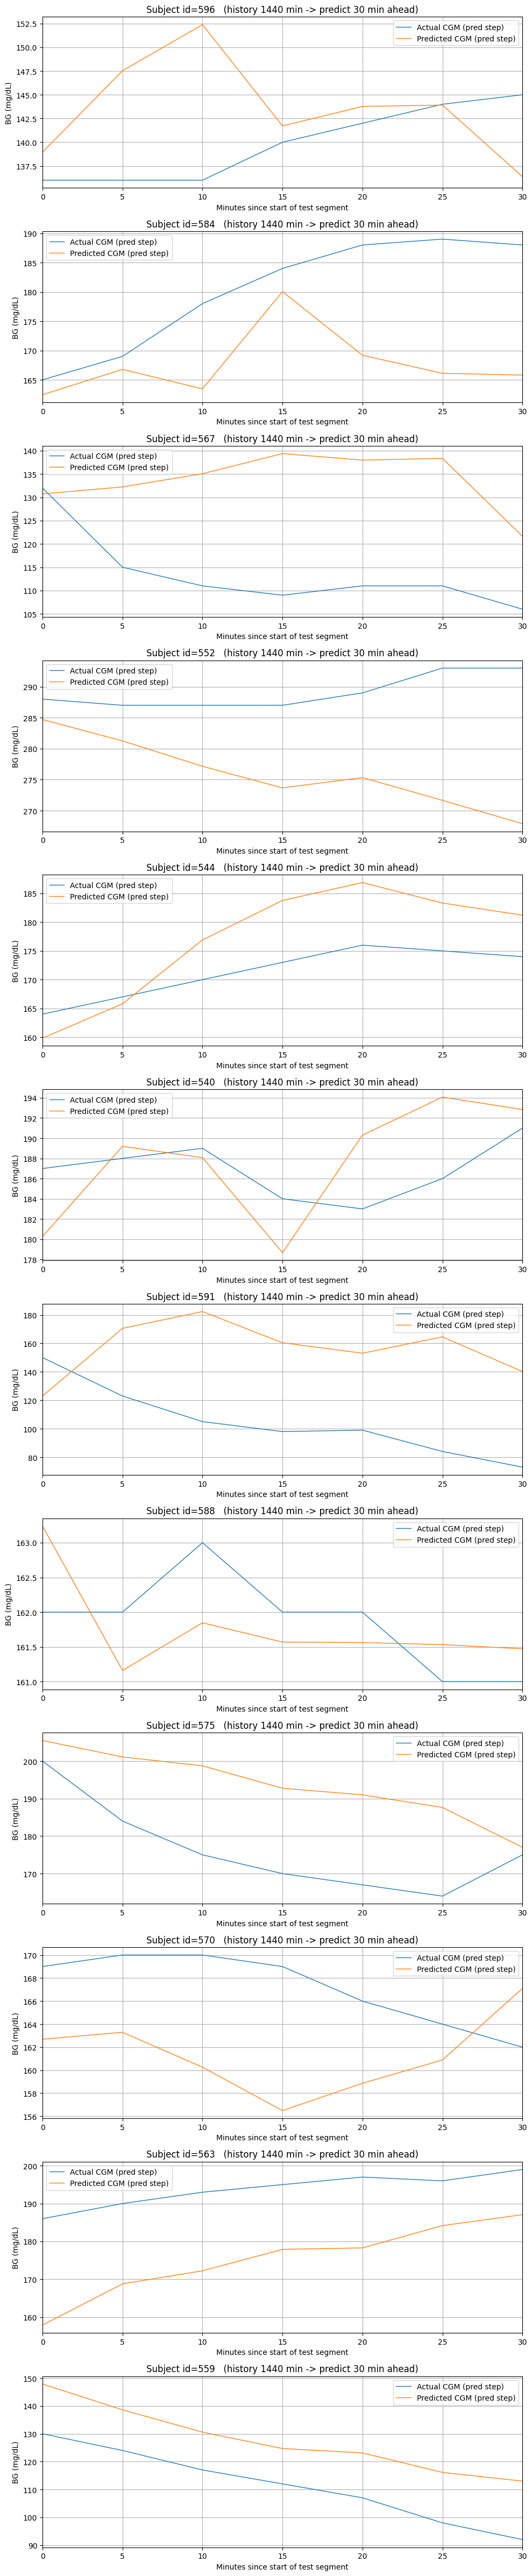

In [1]:
# --- imports & parameters -------------------------------------------------
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ----------------- parameters ---------------------------------------------
DATA_PATH = "../data/OhioT1DM.csv"
n_in = 288           # input window in steps (24 * 5min = 120 min history)
n_out = 6            # output horizon in steps (6*5min = 30 minutes). We will train to predict the final step only.
epochs = 50
batch_size = 32
subjects_to_plot = 3
gap_minutes = 0     # optional temporal gap between train and test in minutes (e.g. 30)
# -------------------------------------------------------------------------

# ----------------- helpers ------------------------------------------------
# sliding windows (no leakage: call only on already split segments)
def make_sequences(values, n_in, n_out):
    X, y = [], []
    for i in range(len(values) - n_in - n_out + 1):
        X.append(values[i:i+n_in])
        y.append(values[i+n_in:i+n_in+n_out, 0])
    return np.array(X), np.array(y)

# invert CGM scaling
def inv_cgm_with_cg_scaler(scaled_vals, cg_scaler):
    # scaled_vals shape: (N, k) where k = number of predicted steps (1 or n_out)
    out = []
    for step_idx in range(scaled_vals.shape[1]):
        col = scaled_vals[:, step_idx].reshape(-1, 1)
        inv = cg_scaler.inverse_transform(col)[:, 0]
        out.append(inv)
    return np.stack(out, axis=1)

# -------------------------------------------------------------------------

# ----------------- read + per-subject raw reindex -------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Data file not found at {DATA_PATH}. Place OhioT1DM.csv next to the notebook.")

print("Reading CSV...")
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
feature_cols = ["CGM","carbs","bolus","basal","galvanic_skin_response","skin_temp",
                "acceleration","workout_intensity","workout_duration","heartrate","air_temp","steps"]

ids = df['id'].unique()
print(f"Using subject ids: {ids}")

# collect reindexed raw arrays per subject (keep NaNs so we can split first)
raw_per_subject = {}
for sid in ids:
    sub = df[df['id']==sid].sort_values('date').copy()
    sub = sub.set_index('date')
    full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='5T')
    sub = sub.reindex(full_idx)
    raw = sub[feature_cols].astype(float).values
    raw_per_subject[sid] = {'raw': raw, 'full_idx': full_idx}

# -------------------------------------------------------------------------

# ----------------- split raw series into train/test per subject -----------
per_subject_slices = {}
train_parts_for_scaler_cg = []
train_parts_for_scaler_others = []

for sid, info in raw_per_subject.items():
    data = info['raw']                # shape (T, n_features)
    full_idx = info['full_idx']
    T = len(data)

    if T < (n_in + n_out + 1):
        print(f"Warning: subject {sid} too short (T={T}) -> skipping.")
        continue

    # chronological raw-sample split
    S = int(0.7 * T)  # split index in raw samples

    gap_samples = int(np.round(gap_minutes / 5.0))
    if S < (n_in + n_out):
        S = n_in + n_out

    train_end = max(0, S - gap_samples)
    test_start = min(T, S + gap_samples)

    df_train = pd.DataFrame(data[:train_end], columns=feature_cols, index=full_idx[:train_end])
    df_test  = pd.DataFrame(data[test_start:], columns=feature_cols, index=full_idx[test_start:])

    if len(df_train) == 0 or len(df_test) == 0:
        df_train = pd.DataFrame(data[:S], columns=feature_cols, index=full_idx[:S])
        df_test  = pd.DataFrame(data[S:], columns=feature_cols, index=full_idx[S:])
        print(f"Note: gap removed for subject {sid} because it produced empty split; fallback to direct split.")

    # ---- improved imputation on train only (time interpolation then ffill/bfill) ----
    # interpolate time series within training segment to produce smoother realistic CGM traces
    df_train = df_train.interpolate(method='time', limit_direction='both')
    med = df_train.median(skipna=True).fillna(0.0)
    df_train = df_train.ffill().bfill().fillna(med)

    # impute test using past information: forward-fill within test, then fallback to train medians
    df_test = df_test.ffill().fillna(med)

    train_arr = df_train.values.astype(float)
    test_arr = df_test.values.astype(float)

    per_subject_slices[sid] = {
        'train_raw': train_arr,
        'test_raw': test_arr,
        'train_index': df_train.index,
        'test_index': df_test.index
    }

    # collect for scaler fitting (only training data)
    if train_arr.shape[0] > 0:
        train_parts_for_scaler_cg.append(train_arr[:, 0:1])
        train_parts_for_scaler_others.append(train_arr[:, 1:])

# check
if len(train_parts_for_scaler_cg) == 0:
    raise RuntimeError("No training data after safe splitting. Reduce subjects_to_plot or check data.")

print("Per-subject raw splits created (train/test).")

# ----------------- fit scalers on training-only data ----------------------
all_train_cg = np.vstack(train_parts_for_scaler_cg)
all_train_others = np.vstack(train_parts_for_scaler_others)

cg_scaler = MinMaxScaler().fit(all_train_cg)
others_scaler = MinMaxScaler().fit(all_train_others)

print("Fitted global scalers on training data only.")

# ----------------- create sequences separately for train and test ---------
X_train_list = []
y_train_list = []
per_subject_test = {}

for sid, slices in per_subject_slices.items():
    train_raw = slices['train_raw']
    test_raw = slices['test_raw']
    train_idx = slices['train_index']
    test_idx = slices['test_index']

    # scale using scalers fit on training data
    if train_raw.shape[0] > 0:
        train_cg_scaled = cg_scaler.transform(train_raw[:, 0:1])
        train_others_scaled = others_scaler.transform(train_raw[:, 1:])
        train_scaled = np.hstack([train_cg_scaled, train_others_scaled])
    else:
        train_scaled = np.empty((0, train_raw.shape[1]))

    if test_raw.shape[0] > 0:
        test_cg_scaled = cg_scaler.transform(test_raw[:, 0:1])
        test_others_scaled = others_scaler.transform(test_raw[:, 1:])
        test_scaled = np.hstack([test_cg_scaled, test_others_scaled])
    else:
        test_scaled = np.empty((0, test_raw.shape[1]))

    # make sequences inside each segment (windows will not cross the split boundary)
    X_tr, y_tr = make_sequences(train_scaled, n_in, n_out) if train_scaled.shape[0] >= (n_in + n_out) else (np.zeros((0, n_in, train_scaled.shape[1])), np.zeros((0, n_out)))
    X_te, y_te = make_sequences(test_scaled, n_in, n_out) if test_scaled.shape[0] >= (n_in + n_out) else (np.zeros((0, n_in, test_scaled.shape[1])), np.zeros((0, n_out)))

    if len(X_tr) > 0:
        X_train_list.append(X_tr)
        y_train_list.append(y_tr)
    else:
        print(f"Warning: subject {sid} ended up with 0 train windows after safe slicing.")

    # timestamps for test windows: use test_idx; timestamps correspond to the final predicted step
    if len(y_te) > 0:
        timestamps_test = test_idx[n_in : n_in + len(y_te)] + pd.to_timedelta(5*(n_out-1), unit='m')
    else:
        timestamps_test = pd.DatetimeIndex([])

    per_subject_test[sid] = {
        'X_test': X_te,
        'y_test': y_te,
        'times_test': timestamps_test
    }

# build global training arrays
if len(X_train_list) == 0:
    raise RuntimeError("No training windows collected across subjects.")

X_train_all = np.vstack(X_train_list)
y_train_all = np.vstack(y_train_list)

print(f"Global training samples (safe split): {len(X_train_all)}")

# ----------------- target simplification: predict only final horizon step ----
# Instead of learning all intermediate steps, focus the network on the final predicted step
# This changes y_train from shape (N, n_out) to (N, 1), preventing the model from spending capacity
# on predicting earlier horizons you don't evaluate.
y_train_all = y_train_all[:, -1:].astype(np.float32)  # final-step target (keep 2D shape for Keras)

# ----------------- build model and train ---------------------------------
n_features = X_train_all.shape[2]

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(n_in, n_features)),
    LSTM(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)  # single-step output (final horizon)
])

# Optimizer tweaks: lower LR + gradient clipping to stabilize learning
opt = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)

# Huber loss reduces sensitivity to outliers (often helps RMSE in CGM tasks)
model.compile(optimizer=opt, loss=tf.keras.losses.Huber(), metrics=['mse', 'mae'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_all, y_train_all,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    shuffle=True,
    validation_split=0.1,
    callbacks=callbacks
)

# ----------------- per-subject evaluation & plotting ---------------------
plt.figure(figsize=(10, 4 * len(per_subject_test)))
all_preds = []
all_actuals = []
print("\nPer-subject evaluation (RMSE / MAE):")
for idx_i, sid in enumerate(per_subject_test.keys()):
    info = per_subject_test[sid]
    X_test = info['X_test']
    y_test = info['y_test']  # shape (N, n_out)
    times_test = info['times_test']

    if len(X_test) == 0:
        print(f"No test samples for subject {sid}, skipping plot.")
        continue

    # model now predicts only final step
    y_pred = model.predict(X_test, batch_size=batch_size)  # shape (N,1)

    # invert CGM scaling for (final) step
    y_test_last = y_test[:, -1:].astype(np.float32)  # scaled target (final step)
    y_test_inv = inv_cgm_with_cg_scaler(y_test_last, cg_scaler)  # shape (N,1)
    y_pred_inv = inv_cgm_with_cg_scaler(y_pred, cg_scaler)       # shape (N,1)

    actual_30 = y_test_inv[:, 0]
    pred_30 = y_pred_inv[:, 0]

    # compute metrics
    rmse = np.sqrt(mean_squared_error(actual_30, pred_30))
    mae = mean_absolute_error(actual_30, pred_30)
    print(f"  subject {sid}: RMSE = {rmse:.3f}  MAE = {mae:.3f}   (n_test={len(actual_30)})")

    all_preds.append(pred_30)
    all_actuals.append(actual_30)

    # minutes since start of this subject's test portion
    if len(times_test) > 0:
        t0 = times_test[0]
        minutes = np.array([(t - t0).total_seconds() / 60.0 for t in times_test])
    else:
        minutes = np.arange(len(actual_30)) * 5.0

    # only show up to 30 minutes (mask)
    mask = minutes <= 30.0
    if mask.sum() == 0:
        idx_plot = np.arange(min(30, len(minutes)))
        minutes_plot = minutes[idx_plot]
        actual_plot = actual_30[idx_plot]
        pred_plot = pred_30[idx_plot]
    else:
        minutes_plot = minutes[mask]
        actual_plot = actual_30[mask]
        pred_plot = pred_30[mask]

    ax = plt.subplot(len(per_subject_test), 1, idx_i+1)
    ax.plot(minutes_plot, actual_plot, label='Actual CGM (pred step)', linewidth=1)
    ax.plot(minutes_plot, pred_plot, label='Predicted CGM (pred step)', linewidth=1)
    ax.set_ylabel('BG (mg/dL)')
    ax.set_xlabel('Minutes since start of test segment')
    ax.set_title(f'Subject id={sid}   (history {n_in*5} min -> predict {n_out*5} min ahead)')
    ax.set_xlim(0, 30)
    ax.legend()
    ax.grid(True)

plt.tight_layout()

# overall metrics
if len(all_preds) > 0:
    all_preds_concat = np.concatenate(all_preds)
    all_actuals_concat = np.concatenate(all_actuals)
    overall_rmse = np.sqrt(mean_squared_error(all_actuals_concat, all_preds_concat))
    overall_mae = mean_absolute_error(all_actuals_concat, all_preds_concat)
    print(f"\nOverall test: RMSE = {overall_rmse:.3f}  MAE = {overall_mae:.3f}")
else:
    print("No test predictions to evaluate.")

print("Done.")
# -------------------------------------------------------------------------


154/154 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step
143/143 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step
Glucose RMSE (mg/dL): 26.743
Glucose MAE  (mg/dL): 15.749
GluPredKit not importable in this environment. Attempting to pip-install it now...
Automatic install/import of GluPredKit failed. Falling back to compact local Clarke implementation.

Clarke error grid counts & % (zone: (count, %)):
  A: 47072 (87.53%)
  B: 6624 (12.32%)
  D: 78 (0.15%)
  C: 4 (0.01%)

Parkes error grid counts & % (zone: (count, %)):
  A: 46833 (87.09%)
  B: 4575 (8.51%)
  C: 1639 (3.05%)
  E: 649 (1.21%)


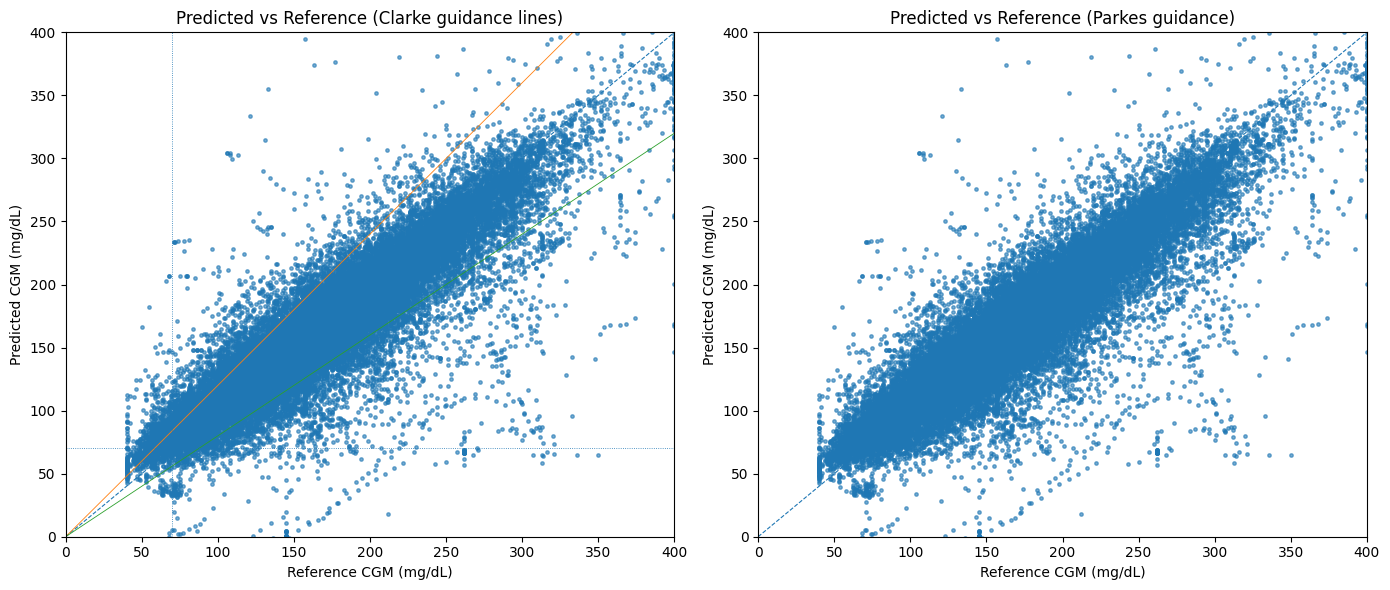


Done. Notes:
- RMSE/MAE shown above are on the final predicted step (same as plotted).
- Clarke/Parkes zone calculations: attempted to use GluPredKit (recommended).
- If GluPredKit wasn't available, the script used a compact fallback classifier for quick diagnostics.
- For clinical/regulatory use, evaluate with a validated implementation (e.g. GluPredKit or the dedicated Python implementations).


In [2]:
# --- new evaluation cell: RMSE, MAE, Clarke + Parkes error grids -----------
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import sys, subprocess

# Collect final-step true/pred across subjects
y_true_list = []
y_pred_list = []

for sid, info in per_subject_test.items():
    X_test = info['X_test']
    y_test = info['y_test']
    if len(X_test) == 0:
        continue
    # predict (model in memory)
    y_pred = model.predict(X_test, batch_size=batch_size)
    # invert scaling to mg/dL using helper from your notebook
    y_test_inv = inv_cgm_with_cg_scaler(y_test, cg_scaler)
    y_pred_inv = inv_cgm_with_cg_scaler(y_pred, cg_scaler)
    # choose last step of n_out (same used in your plotting cell)
    actual_final = y_test_inv[:, -1]
    pred_final   = y_pred_inv[:, -1]

    y_true_list.append(actual_final)
    y_pred_list.append(pred_final)

if len(y_true_list) == 0:
    raise RuntimeError("No test predictions were found across subjects (check per_subject_test).")

y_true = np.concatenate(y_true_list)
y_pred = np.concatenate(y_pred_list)

# Basic metrics
glucose_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
glucose_mae  = mean_absolute_error(y_true, y_pred)

print(f"Glucose RMSE (mg/dL): {glucose_rmse:.3f}")
print(f"Glucose MAE  (mg/dL): {glucose_mae:.3f}")

# --- Try to use GluPredKit (provides ready-made Clarke/Parkes functions) ---
use_glupredkit = True
clarke_zones = None
parkes_zones = None

try:
    # try import
    import glupredkit
    # The package organizes metrics inside glupredkit.evaluation.* - try typical paths
    try:
        from glupredkit.evaluation.metrics import clarke_error_grid, parkes_error_grid
    except Exception:
        # fallback: try alternate import path
        from glupredkit.metrics import clarke_error_grid, parkes_error_grid  # some versions?
except Exception as e:
    print("GluPredKit not importable in this environment. Attempting to pip-install it now...")
    try:
        # install into the running environment (works in notebooks)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "GluPredKit"], stdout=subprocess.DEVNULL)
        import glupredkit
        try:
            from glupredkit.evaluation.metrics import clarke_error_grid, parkes_error_grid
        except Exception:
            from glupredkit.metrics import clarke_error_grid, parkes_error_grid
    except Exception as e2:
        print("Automatic install/import of GluPredKit failed. Falling back to compact local Clarke implementation.")
        use_glupredkit = False

# If GluPredKit is available, call it and get zone breakdowns
if use_glupredkit:
    try:
        # GluPredKit expects arrays in mg/dL. Many versions accept (reference, test) or (test, reference) -> try known signature.
        # First try common call signature (reference_values, test_values)
        cz = clarke_error_grid(y_true, y_pred)
        # Many implementations return zone labels per sample (0->A,1->B...), or dictionary; attempt to normalize
        if isinstance(cz, dict):
            clarke_zones = cz
        else:
            # if list/array, compute counts
            cz = np.asarray(cz)
            unique, counts = np.unique(cz, return_counts=True)
            clarke_zones = dict(zip(unique.tolist(), counts.tolist()))
    except Exception:
        # alternate signature: some versions provide function that returns a tuple (plotobj, zones)
        try:
            out = clarke_error_grid(y_true, y_pred)
            # out could be (fig, zones)
            if isinstance(out, tuple) and len(out) >= 2:
                zones = out[1]
                # zones might be a list of zone labels
                unique, counts = np.unique(zones, return_counts=True)
                clarke_zones = dict(zip(unique.tolist(), counts.tolist()))
        except Exception:
            clarke_zones = None

    try:
        pz = parkes_error_grid(y_true, y_pred, 'type1')  # some implementations accept type argument
        if isinstance(pz, dict):
            parkes_zones = pz
        else:
            pz = np.asarray(pz)
            unique, counts = np.unique(pz, return_counts=True)
            parkes_zones = dict(zip(unique.tolist(), counts.tolist()))
    except Exception:
        # try alternative signature
        try:
            out = parkes_error_grid(y_true, y_pred)
            if isinstance(out, tuple) and len(out) >= 2:
                zones = out[1]
                unique, counts = np.unique(zones, return_counts=True)
                parkes_zones = dict(zip(unique.tolist(), counts.tolist()))
        except Exception:
            parkes_zones = None

# --- Fallback: compact Clarke implementation (zone labels  'A','B','C','D','E') ---
def clarke_zone_for_point(ref, pred):
    """
    Compact Clarke zone classifier:
     - Zone A: if (ref >= 70 and abs(pred - ref) <= 0.2*ref) OR (ref < 70 and abs(pred - ref) <= 20)
     - Zone E: if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330)  # extreme misclassification
     - The rest are approximated into B/C/D (B = clinically acceptable; C/D = errors).
    NOTE: This is a compact/robust fallback — for regulatory/clinical use use a validated library.
    """
    if np.isnan(ref) or np.isnan(pred):
        return None
    # Zone A rules
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20):
        return 'A'
    # extreme opposite (rough heuristic for E)
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330):
        return 'E'
    # If prediction would lead to unnecessary treatment (approx): large overestimation when ref is low
    if ref < 70 and pred >= 180:
        return 'C'  # might cause unnecessary treatment
    # Failure to detect dangerous condition: ref high but pred low (approx)
    if ref >= 180 and pred < 70:
        return 'D'
    # Otherwise mark B (clinically acceptable but outside A)
    return 'B'

if clarke_zones is None:
    zones = [clarke_zone_for_point(r, p) for r, p in zip(y_true, y_pred)]
    # count labels
    from collections import Counter
    c = Counter(zones)
    clarke_zones = dict(c)

# Parkes fallback (simple heuristic): we will bucket into A/B/C/D/E by difference magnitude with some clinical thresholds.
# This is a coarse fallback — prefer GluPredKit or kriventsov implementation for exact Parkes mapping.
if parkes_zones is None:
    def parkes_zone_for_point(ref, pred):
        if np.isnan(ref) or np.isnan(pred):
            return None
        err = pred - ref
        rel_err = abs(err) / max(ref, 1.0)
        # very rough heuristic mapping inspired by Parkes (NOT exact)
        if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2):
            return 'A'
        if rel_err <= 0.35:
            return 'B'
        if (ref < 70 and pred > 180) or (ref > 180 and pred < 70):
            return 'D'  # potential hazardous mis-detection
        if rel_err > 0.6:
            return 'E'
        return 'C'

    pzones = [parkes_zone_for_point(r, p) for r, p in zip(y_true, y_pred)]
    from collections import Counter
    parkes_zones = dict(Counter(pzones))

# Convert counts to percentages and print
def zones_to_percent(zones_dict, total):
    out = {}
    for k, v in zones_dict.items():
        if k is None:
            continue
        out[str(k)] = (v, 100.0 * v / total)
    return out

total = len(y_true)
print("\nClarke error grid counts & % (zone: (count, %)):")
for z, (ct, pct) in zones_to_percent(clarke_zones, total).items():
    print(f"  {z}: {ct} ({pct:.2f}%)")

print("\nParkes error grid counts & % (zone: (count, %)):")
for z, (ct, pct) in zones_to_percent(parkes_zones, total).items():
    print(f"  {z}: {ct} ({pct:.2f}%)")

# --- Optional: scatter plot with Clarke grid lines (visual) ----------------
# We'll plot Pred vs Ref and overlay simple Clarke grid guide lines (diagonal +/-20% and hypoglycemia band).
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Pred (y) vs Ref (x)
ax0 = ax[0]
ax0.scatter(y_true, y_pred, s=6, alpha=0.6)
ax0.plot([0, 400], [0, 400], '--', linewidth=0.8)  # identity
# 20% lines
xs = np.linspace(0, 400, 100)
ax0.plot(xs, 1.2 * xs, linewidth=0.6)
ax0.plot(xs, 0.8 * xs, linewidth=0.6)
# hypoglycemia vertical and horizontal marker lines (70 ± 20 rule)
ax0.axvline(70, linestyle=':', linewidth=0.6)
ax0.axhline(70, linestyle=':', linewidth=0.6)
ax0.set_xlim(0, 400)
ax0.set_ylim(0, 400)
ax0.set_xlabel('Reference CGM (mg/dL)')
ax0.set_ylabel('Predicted CGM (mg/dL)')
ax0.set_title('Predicted vs Reference (Clarke guidance lines)')

# Parkes-style scatter (right panel) - we reuse same scatter; Parkes true boundaries are more complex,
# but the plot is useful visually alongside the computed zone percentages.
ax1 = ax[1]
ax1.scatter(y_true, y_pred, s=6, alpha=0.6)
ax1.plot([0,400],[0,400],'--', linewidth=0.8)
ax1.set_xlim(0, 400)
ax1.set_ylim(0, 400)
ax1.set_xlabel('Reference CGM (mg/dL)')
ax1.set_ylabel('Predicted CGM (mg/dL)')
ax1.set_title('Predicted vs Reference (Parkes guidance)')

plt.tight_layout()
plt.show()

print("\nDone. Notes:")
print("- RMSE/MAE shown above are on the final predicted step (same as plotted).")
print("- Clarke/Parkes zone calculations: attempted to use GluPredKit (recommended).")
print("- If GluPredKit wasn't available, the script used a compact fallback classifier for quick diagnostics.")
print("- For clinical/regulatory use, evaluate with a validated implementation (e.g. GluPredKit or the dedicated Python implementations).")
# -------------------------------------------------------------------------


154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step
143/143 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step
LSTM metrics (final predicted step):
  Glucose RMSE (mg/dL): 26.743
  Glucose MAE  (mg/dL): 15.749
  Evaluated samples: 53778
Installing GluPredKit for exact Clarke/Parkes... (may take a moment)
GluPredKit not available — using compact fallback implementations for Clarke & Parkes.

Clarke error grid (zone : count, %):
  A: 47072 (87.53%)
  B: 6624 (12.32%)
  C: 4 (0.01%)
  D: 78 (0.15%)

Parkes error grid (zone : count, %):
  A: 46833 (87.09%)
  B: 4575 (8.51%)
  C: 1639 (3.05%)


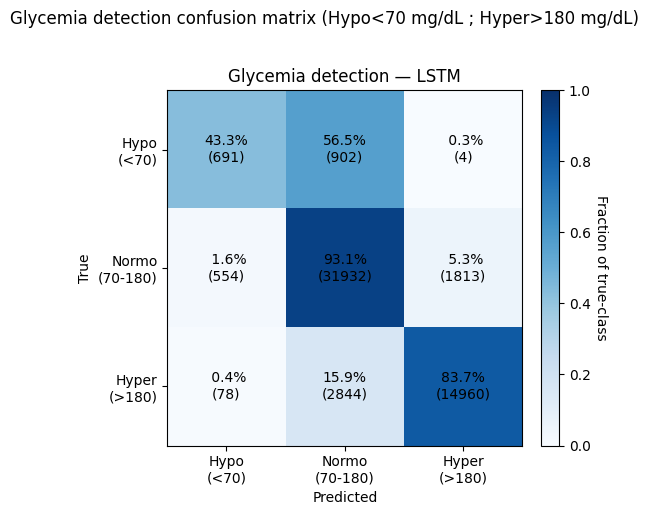


LSTM (percent + count):


,Pred_Hypo,Pred_Normo,Pred_Hyper
True_Hypo,43.3% (691),56.5% (902),0.3% (4)
True_Normo,1.6% (554),93.1% (31932),5.3% (1813)
True_Hyper,0.4% (78),15.9% (2844),83.7% (14960)



Done. Notes:
- Clarke/Parkes zone breakdowns: preferred exact implementation via GluPredKit; otherwise fallback heuristics were used.
- RMSE/MAE and confusion matrix are computed on the final predicted step (same as your plots).


In [3]:
# --- LSTM-only evaluation cell: RMSE, MAE, Clarke & Parkes zones, Glycemia confusion matrices ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import sys, subprocess

# --- Build y_true, y_pred for final predicted step across subjects -----------------------
def collect_lstm_predictions(per_subject_test, model, cg_scaler, batch_size):
    y_true_list = []
    y_pred_list = []
    for sid, info in per_subject_test.items():
        X_test = info['X_test']
        y_test = info['y_test']
        if len(X_test) == 0:
            continue
        y_pred_scaled = model.predict(X_test, batch_size=batch_size)
        y_test_inv = inv_cgm_with_cg_scaler(y_test, cg_scaler)      # shape (N, n_out)
        y_pred_inv = inv_cgm_with_cg_scaler(y_pred_scaled, cg_scaler)
        actual_final = y_test_inv[:, -1]
        pred_final   = y_pred_inv[:, -1]
        y_true_list.append(actual_final)
        y_pred_list.append(pred_final)
    if len(y_true_list) == 0:
        return np.array([]), np.array([])
    return np.concatenate(y_true_list), np.concatenate(y_pred_list)

y_true, y_pred = collect_lstm_predictions(per_subject_test, model, cg_scaler, batch_size)
if y_true.size == 0:
    raise RuntimeError("No LSTM test predictions found. Check per_subject_test content.")

# --- Basic numeric metrics ----------------------------------------------------------------
glucose_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
glucose_mae  = mean_absolute_error(y_true, y_pred)

print(f"LSTM metrics (final predicted step):")
print(f"  Glucose RMSE (mg/dL): {glucose_rmse:.3f}")
print(f"  Glucose MAE  (mg/dL): {glucose_mae:.3f}")
print(f"  Evaluated samples: {len(y_true)}")

# --- Clarke & Parkes error grids (try GluPredKit, else fallback heuristics) ----------------
use_glupredkit = True
clarke_zones = None
parkes_zones = None

try:
    import glupredkit
    try:
        from glupredkit.evaluation.metrics import clarke_error_grid, parkes_error_grid
    except Exception:
        from glupredkit.metrics import clarke_error_grid, parkes_error_grid
except Exception:
    # attempt to install
    try:
        print("Installing GluPredKit for exact Clarke/Parkes... (may take a moment)")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "GluPredKit"], stdout=subprocess.DEVNULL)
        import glupredkit
        try:
            from glupredkit.evaluation.metrics import clarke_error_grid, parkes_error_grid
        except Exception:
            from glupredkit.metrics import clarke_error_grid, parkes_error_grid
    except Exception:
        print("GluPredKit not available — using compact fallback implementations for Clarke & Parkes.")
        use_glupredkit = False

if use_glupredkit:
    try:
        # typical signature: clarke_error_grid(reference, test) -> per-sample zone labels or dict
        cz = clarke_error_grid(y_true, y_pred)
        if isinstance(cz, dict):
            clarke_zones = cz
        else:
            cz = np.asarray(cz)
            unique, counts = np.unique(cz, return_counts=True)
            clarke_zones = dict(zip(unique.tolist(), counts.tolist()))
    except Exception:
        clarke_zones = None
    try:
        pz = parkes_error_grid(y_true, y_pred)
        if isinstance(pz, dict):
            parkes_zones = pz
        else:
            pz = np.asarray(pz)
            unique, counts = np.unique(pz, return_counts=True)
            parkes_zones = dict(zip(unique.tolist(), counts.tolist()))
    except Exception:
        parkes_zones = None

# --- Fallback Clarke/ Parkes (compact, diagnostic heuristics) -----------------------------
def clarke_zone_for_point(ref, pred):
    """Compact Clarke zone classifier (heuristic fallback)."""
    if np.isnan(ref) or np.isnan(pred):
        return None
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20):
        return 'A'
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330):
        return 'E'
    if ref < 70 and pred >= 180:
        return 'C'
    if ref >= 180 and pred < 70:
        return 'D'
    return 'B'

def parkes_zone_for_point(ref, pred):
    """Coarse Parkes heuristic (diagnostic only)."""
    if np.isnan(ref) or np.isnan(pred):
        return None
    err = pred - ref
    rel_err = abs(err) / max(ref, 1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2):
        return 'A'
    if rel_err <= 0.35:
        return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70):
        return 'D'
    if rel_err > 0.6:
        return 'E'
    return 'C'

if clarke_zones is None:
    cz = [clarke_zone_for_point(r, p) for r, p in zip(y_true, y_pred)]
    unique, counts = np.unique(cz, return_counts=True)
    clarke_zones = dict(zip(unique.tolist(), counts.tolist()))

if parkes_zones is None:
    pz = [parkes_zone_for_point(r, p) for r, p in zip(y_true, y_pred)]
    unique, counts = np.unique(pz, return_counts=True)
    parkes_zones = dict(zip(unique.tolist(), counts.tolist()))

# Print zone breakdowns (counts + percentages)
def zones_to_percent(zdict, total):
    out = {}
    for k, v in zdict.items():
        if k is None:
            continue
        out[str(k)] = (int(v), 100.0 * int(v) / total)
    return out

total = len(y_true)
print("\nClarke error grid (zone : count, %):")
for z, (ct, pct) in zones_to_percent(clarke_zones, total).items():
    print(f"  {z}: {ct} ({pct:.2f}%)")

print("\nParkes error grid (zone : count, %):")
for z, (ct, pct) in zones_to_percent(parkes_zones, total).items():
    print(f"  {z}: {ct} ({pct:.2f}%)")

# --- Glycemia detection confusion matrices ------------------------------
HYPO = 70
HYPER = 180

def glycemia_class(x, hypo=HYPO, hyper=HYPER):
    x = np.asarray(x)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < hypo] = 0
    cls[(x >= hypo) & (x <= hyper)] = 1
    cls[x > hyper] = 2
    return cls

def compute_glycemia_confusion(y_true, y_pred, hypo=HYPO, hyper=HYPER):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]; y_pred = y_pred[mask]
    counts = np.zeros((3,3), dtype=int)
    if y_true.size == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)
    true_cls = glycemia_class(y_true, hypo=hypo, hyper=hyper)
    pred_cls = glycemia_class(y_pred, hypo=hypo, hyper=hyper)
    for t, p in zip(true_cls, pred_cls):
        if 0 <= t <= 2 and 0 <= p <= 2:
            counts[t, p] += 1
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        row_sum = counts[i].sum()
        if row_sum > 0:
            pct[i, :] = counts[i, :] / float(row_sum)
        else:
            pct[i, :] = np.nan
    return counts, pct

def plot_confusion_heatmaps(counts, pct, ax, title="", cmap='Blues'):
    im = ax.imshow(pct, vmin=0.0, vmax=1.0, cmap=cmap, interpolation='nearest')
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    labels = ['Hypo\n(<70)', 'Normo\n(70-180)', 'Hyper\n(>180)']
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            c = counts[i, j]
            p = pct[i, j]
            if np.isnan(p):
                txt = "n/a\n(0)"
            else:
                txt = f"{p*100:4.1f}%\n({c})"
            ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel('Fraction of true-class', rotation=270, labelpad=12)

counts_lstm, pct_lstm = compute_glycemia_confusion(y_true, y_pred)

print("\nGlycemia detection — counts (rows=true, cols=pred) [LSTM]:\n", counts_lstm)
print("\nGlycemia detection — percentages (row-normalized) [LSTM]:\n", np.round(pct_lstm * 100, 2))

# Plot heatmap
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
plot_confusion_heatmaps(counts_lstm, pct_lstm, ax, title="Glycemia detection — LSTM")
plt.suptitle(f"Glycemia detection confusion matrix (Hypo<{HYPO} mg/dL ; Hyper>{HYPER} mg/dL)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Combined table for glance
import pandas as pd
def df_from_confusion(pct, counts):
    rows = ['True_Hypo', 'True_Normo', 'True_Hyper']
    cols = ['Pred_Hypo', 'Pred_Normo', 'Pred_Hyper']
    table = [[ (f"{(pct[i,j]*100):4.1f}% ({counts[i,j]})" if not np.isnan(pct[i,j]) else "n/a (0)")
               for j in range(3)] for i in range(3)]
    return pd.DataFrame(table, index=rows, columns=cols)

print("\nLSTM (percent + count):")
display(df_from_confusion(pct_lstm, counts_lstm))

print("\nDone. Notes:")
print("- Clarke/Parkes zone breakdowns: preferred exact implementation via GluPredKit; otherwise fallback heuristics were used.")
print("- RMSE/MAE and confusion matrix are computed on the final predicted step (same as your plots).")
